In [1]:
import sys;from pathlib import Path;sys.path.insert(0, str(Path().resolve()))

import torch
from transformers import CLIPTokenizer
from PIL import Image
from IPython.display import display, clear_output
import random

from module import model_loader, pipeline

torch.set_float32_matmul_precision('high')

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else 'cpu'
DTYPE = torch.bfloat16 if DEVICE=="cuda" else torch.bfloat32
MODEL_PATH = "model/Anime-Background-Finetuning-diffusion.safetensors"
TOKENIZER_VOCAB = "tokenizer/vocab.json"
TOKENIZER_MERGES = "tokenizer/merges.txt"

In [3]:
tokenizer = CLIPTokenizer(TOKENIZER_VOCAB, TOKENIZER_MERGES)
models = model_loader.get_models(MODEL_PATH, device=DEVICE, dtype=DTYPE)

🔄 Initializing vae, clip and diffusion...
> Loading encoder from model/Anime-Background-Finetuning-diffusion.safetensors...
> Loading decoder from model/Anime-Background-Finetuning-diffusion.safetensors...
> Loading clip from model/Anime-Background-Finetuning-diffusion.safetensors...
> Loading diffusion from model/Anime-Background-Finetuning-diffusion.safetensors...
✅ Initialization successful!


In [6]:
prompt = (
    "airfish_(lefko_d), architecture, blue sky, blurry, boat, broken window, "
    "building, city, day, depth of field, drum (container), no humans, outdoors, "
    "ruins, scenery, science fiction, sign, signature, sky, water, watercraft"
)
gen_params = {
    "prompt": prompt,
    "uncond_prompt": "",
    "img_width": 512,
    "img_height": 512,
    "input_image": None, # Image.open("image/image_0001.png").convert("RGB")
    "strength": 0.8,
    "do_cfg": True,
    "cfg_scale": 7.5,
    "sampler_name": "ddpm",
    "n_inference_steps": 32,
    "num_training_steps": 1000,
    "models": models,
    "seed": random.randint(0, int(1e9)),
    "device": DEVICE,
    "dtype": DTYPE,
    "tokenizer": tokenizer,
    "ddim_eta": 0.1,
    "decode_interval": 6,
}

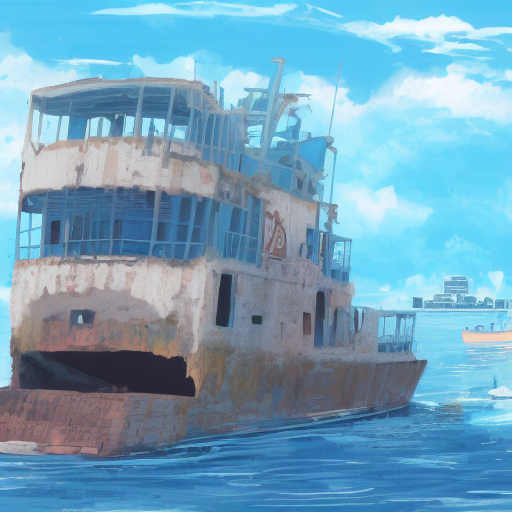

Sampling: 100%|██████████| 33/33 [00:07<00:00,  4.31step/s]


In [7]:
generator = pipeline.generate(**gen_params)

for output_image in generator:
    pil_img = Image.fromarray(output_image[0])
    clear_output(wait=True)
    display(pil_img)